In [1]:
library(dplyr)
library(corrplot)
# single-cell analysis package
library(dplyr)
library(dittoSeq)
library(reticulate)

# plotting and data science packages
library(tidyverse)
library(cowplot)
library(patchwork)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


corrplot 0.92 loaded

Loading required package: ggplot2

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
✔ readr     2.1.5     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘cowplot’


The following object is masked from ‘package:lubridate’:

    stamp



Attachi

Sigantures from Sun et al. 2024. https://doi.org/10.1016/j.cell.2023.08.037

In [2]:
signatures <- readxl::read_excel('mmc1.xlsx',
                                  sheet = "Page 2.StateMarkers")
signatures

p_val,avg_log2FC,pct.1,pct.2,p_val_adj,microgliaState,gene
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
0,0.7135225,0.737,0.457,0,MG0,RASGEF1C
0,0.6878487,0.354,0.169,0,MG0,PRDM11
0,0.6869559,0.819,0.536,0,MG0,P2RY12
0,0.6140870,0.573,0.433,0,MG0,GRID2
0,0.5892958,0.894,0.687,0,MG0,SYNDIG1
0,0.5795445,0.717,0.499,0,MG0,KHDRBS3
0,0.5706286,0.833,0.588,0,MG0,FOXP2
0,0.5654836,0.623,0.381,0,MG0,CX3CR1
0,0.5561606,0.508,0.299,0,MG0,TANC1


In [3]:
mg_states <- unique(signatures$microgliaState)
mg_states

[1] "MG0"  "MG1"  "MG2"  "MG3"  "MG4"  "MG5"  "MG6"  "MG7"  "MG8"  "MG10"
[11] "MG11" "MG12"

In [5]:
signatures_list <- list()

for (i in mg_states) {
                gene.names <- signatures %>% filter(microgliaState==i) %>% top_n(50, wt=avg_log2FC) %>%pull(gene)
                signatures_list <- append(signatures_list, list(as.character(na.omit(gene.names))))
}
names(signatures_list) <- c('Homeostatic',
'Neuronal Surveillance',
'Inflammatory I',
'Ribosome Biogenesis',
'Lipid Processing',
'Phagocytic',
'Stress Signature',
'Glycolytic',
'Inflammatory II',
'Inflammatory III',
'Antiviral',
'Cycling')
signatures_list

$Homeostatic
 [1] "RASGEF1C"   "PRDM11"     "P2RY12"     "GRID2"      "SYNDIG1"   
 [6] "KHDRBS3"    "FOXP2"      "CX3CR1"     "TANC1"      "ST6GALNAC3"
[11] "PTCHD4"     "KBTBD12"    "P3H2"       "HS3ST4"     "NAV3"      
[16] "KCNIP1"     "IL6ST"      "TIAM1"      "MRC1"       "PIP5K1B"   
[21] "CPED1"      "SDK1"       "TLN2"       "C12orf75"   "CSGALNACT1"
[26] "C4orf19"    "FRMD4A"     "NAV2"       "BLNK"       "ABCC4"     
[31] "OXR1"       "ANKRD44"    "KLF12"      "CACNA1A"    "SLC15A2"   
[36] "IFNGR1"     "TMEM156"    "NLRP1"      "DEPTOR"     "DIP2A"     
[41] "RTTN"       "SESN3"      "PGM5"       "ADAMTSL2"   "EML1"      
[46] "TBC1D4"     "LPAR1"      "TENM4"      "APPL2"      "ARHGAP22"  

$`Neuronal Surveillance`
 [1] "FRMD4A"   "INO80D"   "GOLGB1"   "MLXIPL"   "RBM25"    "RASGEF1B"
 [7] "ZNF846"   "ZMAT1"    "MPHOSPH8" "PRAM1"    "BOD1L1"   "WNT2B"   
[13] "NKTR"     "MAF"      "LINGO1"   "GAK"      "SLC26A3"  "MT-CO3"  
[19] "ABR"      "TIMM23B"  "NLRP1"    "PRRC2C"   "TNRC18"   "SON"     
[25] "PRPF38B"  "RYR1"     "CSF2RA"   "SRRM2"    "MT-CO2"   "CACNA1A" 
[31] "MT-ATP6"  "AOAH"     "SYNDIG1"  "RASGEF1C" "C3"       "MT-ND2"  
[37] "CCND3"    "MT-ND4"   "PNISR"    "MT-CYB"   "MT-CO1"  

$`Inflammatory I`
 [1] "TMEM163" "ERC2"    "HAMP"    "LIMK2"   "FAM129A" "PTPN2"   "BCL6"   
 [8] "CPEB4"   "TBC1D8"  "SPATA6"  "FCGBP"   "TBC1D14" "ADGRE2"  "SH3RF3" 
[15] "TGFBR1"  "PIM1"    "BACH1"   "IL4R"    "PRKCA"   "JAK3"    "HRH2"   
[22] "NCK2"    "GRAMD1A" "IKZF2"   "DENND3"  "CD14"    "KLHL2"   "LAP3"   
[29] "IL1RAP"  "HSPA5"   "SPP1"    "RNF149"  "PTPN1"   "SLC2A5"  "VSIG4"  
[36] "MARCH1"  "SLC11A1" "PTPRE"   "GOLGA4"  "ACER3"   "XBP1"    "BIN1"   
[43] "FCGR1A"  "SCFD2"   "RUNX1"   "ANK2"    "PPA1"    "HSP90B1" "PYGL"   
[50] "FCGR3A" 

$`Ribosome Biogenesis`
 [1] "FTL"     "FTH1"    "RPL19"   "TPT1"    "TMSB10"  "RPS6"    "RPL32"  
 [8] "PLEKHA7" "RPS11"   "RPS15"   "RPL11"   "RPS24"   "TMSB4X"  "RPS27A" 
[15] "RPLP1"   "RPL23A"  "RPS4X"   "RPS23"   "RPS25"   "RPS20"   "EEF1A1" 
[22] "RPS8"    "RPL28"   "RPL13"   "AIF1"    "RPL13A"  "RPL8"    "RPL14"  
[29] "RPLP2"   "RPL37A"  "ATP5F1E" "RPS3"    "RPL41"   "RPL27A"  "RPL29"  
[36] "UBA52"   "RPL3"    "RPL10"   "RPL35"   "RPS27"   "RPS2"    "OOEP"   
[43] "RPS18"   "YBX1"    "RPL23"   "FAU"     "RPS19"   "NACA"    "APOO"   
[50] "RPL6"   

$`Lipid Processing`
 [1] "MYO1E"    "PTPRG"    "GPNMB"    "TPRG1"    "CPM"      "STARD13" 
 [7] "NHSL1"    "GLDN"     "PPARG"    "MITF"     "SAMD4A"   "ZNF804A" 
[13] "GAS7"     "XYLT1"    "PLA2G7"   "ATG7"     "NPL"      "FNIP2"   
[19] "ARID5B"   "IQGAP2"   "PRKCE"    "MAFB"     "RTTN"     "DSCAM"   
[25] "SUSD1"    "SH3PXD2A" "ASAH1"    "SOCS6"    "SPIRE1"   "MGLL"    
[31] "TNFAIP2"  "WIPF3"    "KCNMA1"   "OLR1"     "CADM1"    "ITGAX"   
[37] "DENND4C"  "FARP1"    "MTSS1"    "SCIN"     "LGMN"     "DPYD"    
[43] "FMN1"     "TANC2"    "RASGRP3"  "FRMD4B"   "LIPA"     "CD83"    
[49] "KCNJ5"    "SPP1"    

$Phagocytic
 [1] "CD163"    "F13A1"    "DPYD"     "TPRG1"    "ZNF804A"  "IQGAP2"  
 [7] "MCTP1"    "TGFBI"    "EYA2"     "ADGRG6"   "THRB"     "PLXNC1"  
[13] "MS4A4E"   "FAM110B"  "TRPS1"    "FCHO2"    "CD163L1"  "IL15"    
[19] "ARHGAP18" "STARD13"  "APOE"     "MS4A4A"   "CPM"      "MSR1"    
[25] "FMN1"     "DRAM1"    "LRRK2"    "EPB41L3"  "CADM1"    "CLEC5A"  
[31] "IQGAP1"   "MAFB"     "ITSN1"    "IFI44L"   "ESR1"     "MS4A6A"  
[37] "ACSL1"    "FOXP1"    "FCGR2A"   "RHOBTB3"  "SLC2A9"   "GPR155"  
[43] "UTRN"     "ZBTB16"   "CD14"     "KHDRBS2"  "ST7"      "PDE4B"   
[49] "EDA"      "NCKAP5"  

$`Stress Signature`
 [1] "HSP90AA1"  "HSPH1"     "DNAJB1"    "HSPB1"     "HSPD1"     "HSPA1A"   
 [7] "CD83"      "HSPA6"     "BAG3"      "HSPA1B"    "P4HA1"     "BCAS2"    
[13] "UBC"       "SLC2A3"    "DNAJA4"    "PPP1R15A"  "HSP90AB1"  "HMOX1"    
[19] "IER5"      "SERPINH1"  "PTGES3"    "DUSP1"     "FOS"       "SRGN"     
[25] "JUN"       "CHORDC1"   "DNAJB6"    "DNAJA1"    "HSPA8"     "GLUL"     
[31] "DDIT4"     "RGS1

In [6]:
tumor_mg <- list('MP10'=c(
    "DSCAM", "NAV3", "FOXP2", "SYNDIG1", "HS3ST4", "CACNA1D", "MCF2L", "RASGEF1C", 
    "TLN2", "WIPF3", "CDC14B", "KCNIP1", "LARGE1", "SDK1", "TENM4", "CACNA1A", 
    "ERC2", "MYO6", "PKDCC", "ABCC4", "ANK2", "CACNB4", "FAM149A", "KHDRBS3", 
    "LRIG1", "MACROD2", "OXR1", "PADI2", "PLPP1", "SPP1", "ST6GALNAC3", "SULT1C2", 
    "AKT3", "APBA2", "FRMD4A", "IPCEF1", "KCNQ3", "MYO1E", "NLGN4Y", "RAMP1", 
    "RTTN", "TANC1", "WNT5A", "MPDZ", "AUTS2", "BACE2", "ZFYVE9", "MAGI1", "PTPRG", 
    "SH3RF3"
),
                 'MP6'=c(
    "DSCAM", "NAV3", "FOXP2", "SYNDIG1", "HS3ST4", "CACNA1D", "MCF2L", "RASGEF1C", 
    "TLN2", "WIPF3", "CDC14B", "KCNIP1", "LARGE1", "SDK1", "TENM4", "CACNA1A", 
    "ERC2", "MYO6", "PKDCC", "ABCC4", "ANK2", "CACNB4", "FAM149A", "KHDRBS3", 
    "LRIG1", "MACROD2", "OXR1", "PADI2", "PLPP1", "SPP1", "ST6GALNAC3", "SULT1C2", 
    "AKT3", "APBA2", "FRMD4A", "IPCEF1", "KCNQ3", "MYO1E", "NLGN4Y", "RAMP1", 
    "RTTN", "TANC1", "WNT5A", "MPDZ", "AUTS2", "BACE2", "ZFYVE9", "MAGI1", "PTPRG", 
    "SH3RF3"
),
                 'MP12'=c("NBEA", "RFX3", "CLASP2", "MSRA", "PHF14", "CAMTA1", "CASK",
                          "GAB1", "MAP4K5", "RUFY3", "ACACA", "AOPEP", "APC", "DLG1", 
                          "MSI2", "PSD3", "TNKS", "UBE2E3", "ANKIB1", "DST", "EHBP1", 
                          "ERCC6L2", "GPHN", "HIBCH", "KIZ", "LYPLAL1", "MAGED1", "NFIA",
                          "PBX3", "PPP1R12B", "PRKACB", "PTK2", "STXBP5", "TIAM2",
                          "TNRC6A", "TTC3", "TTC37", "UGGT2", "XKR6", "ZNF532", "SLC2A13", 
                          "HSPA4L", "ZDHHC21", "CD47", "FARP1", "OSBPL9", "ELP4", "MAP2K4", "ATXN10", "LRIG1"),
                 'MP13'=c(
    "JAZF1", "MEF2C", "PCNX2", "AOAH", "EPB41L2", "PRKN", "ZDHHC14", "BLNK", "CSGALNACT1", 
    "CTTNBP2", "DLEU7", "ENTPD1", "FRMD4A", "FYB1", "MS4A4E", "RCSD1", "SRGAP2", "DISP1", 
    "FAM135A", "GPR155", "HDAC9", "MERTK", "MVB12B", "PALD1", "PDE4B", "SLC4A7", "SLC9A9", 
    "SLCO2B1", "SPATA6", "SPRED1", "SRGAP1", "SYNDIG1", "CARMIL1", "CD74", "HIVEP3", "KCNQ3", 
    "LY86", "MS4A7", "NAV3", "RNF150", "RTN1", "SSH2", "ST6GAL1", "TCF12", "TCF4", "TLN2", 
    "UBE2E2", "ZNF804A", "SLC8A1", "NEK10"
)
)

## Jaccard similarity

In [20]:
# Function to calculate Jaccard score
jaccard_score <- function(set1, set2) {
  length(intersect(set1, set2)) / length(union(set1, set2))
}

# Function to calculate p-value from Fisher's exact test
fisher_test_pvalue <- function(set1, set2, universe) {
  matrix <- c(
    length(intersect(set1, set2)),
    length(setdiff(set1, set2)),
    length(setdiff(set2, set1)),
    length(setdiff(universe, union(set1, set2)))
  )
  matrix <- matrix(matrix, nrow = 2)
  test <- fisher.test(matrix)
  return(test$p.value)
}

In [21]:
MG <- signatures_list
MP <- tumor_mg

In [22]:
# Get the list of all genes to use as the universe for Fisher's test
all_genes <- unique(unlist(c(MG, MP)))

# Compute Jaccard scores and p-values
results <- expand.grid(MP_names = names(MP), MG_names = names(MG)) %>%
  rowwise() %>%
  mutate(
    Jaccard = jaccard_score(MP[[MP_names]], MG[[MG_names]]),
    P_value = fisher_test_pvalue(MP[[MP_names]], MG[[MG_names]], all_genes),
    Significance = P_value < 0.05
  ) %>%
  ungroup()

In [24]:
# Prepare data for heatmap
heatmap_data <- results %>%
  select(MP_names, MG_names, Jaccard) %>%
  spread(MG_names, Jaccard)

# Prepare matrix
matrix <- as.matrix(heatmap_data[-1])
rownames(matrix) <- heatmap_data$MP_names

In [26]:
# Prepare data for heatmap
significance <- results %>%
  select(MP_names, MG_names, P_value) %>%
  spread(MG_names, P_value)

# Prepare matrix
matrix_significance <- as.matrix(significance[-1])
rownames(matrix_significance) <- significance$MP_names
matrix_significance

,Homeostatic,Neuronal Surveillance,Inflammatory I,Ribosome Biogenesis,Lipid Processing,Phagocytic,Stress Signature,Glycolytic,Inflammatory II,Inflammatory III,Antiviral,Cycling
MP10,2.548127e-08,0.56407772,1.00000000,0.02587625,0.2793162,0.02587625,0.02587625,0.41540925,0.4154093,0.41540925,0.02587625,0.02587625
MP6,2.548127e-08,0.56407772,1.00000000,0.02587625,0.2793162,0.02587625,0.02587625,0.41540925,0.4154093,0.41540925,0.02587625,0.02587625
MP12,2.587625e-02,0.06673679,0.02587625,0.02587625,0.1687020,0.02587625,0.02587625,0.02587625,0.1687020,0.02587625,0.02587625,0.02587625
MP13,2.793162e-01,1.00000000,0.16870196,0.02587625,0.1687020,1.00000000,0.02587625,0.02587625,1.0000000,0.02587625,0.02587625,0.02587625


In [27]:
signif_matrix <- matrix("", nrow = nrow(matrix), ncol = ncol(matrix))
rownames(signif_matrix) <- rownames(matrix)
colnames(signif_matrix) <- colnames(matrix)

# Fill in the signif_matrix with asterisks based on the p-value thresholds
for(i in 1:nrow(matrix_significance)) {
  for(j in 1:ncol(matrix_significance)) {
    p_value <- matrix_significance[i,j]
    if(!is.na(p_value)) {
      if(p_value < 0.0001) {
        signif_matrix[i,j] <- "***"
      } else if(p_value < 0.001) {
        signif_matrix[i,j] <- "**"
      } else if(p_value < 0.01) {
        signif_matrix[i,j] <- "*"
      }
    }
  }
}

In [29]:
library(RColorBrewer)
library(pheatmap)

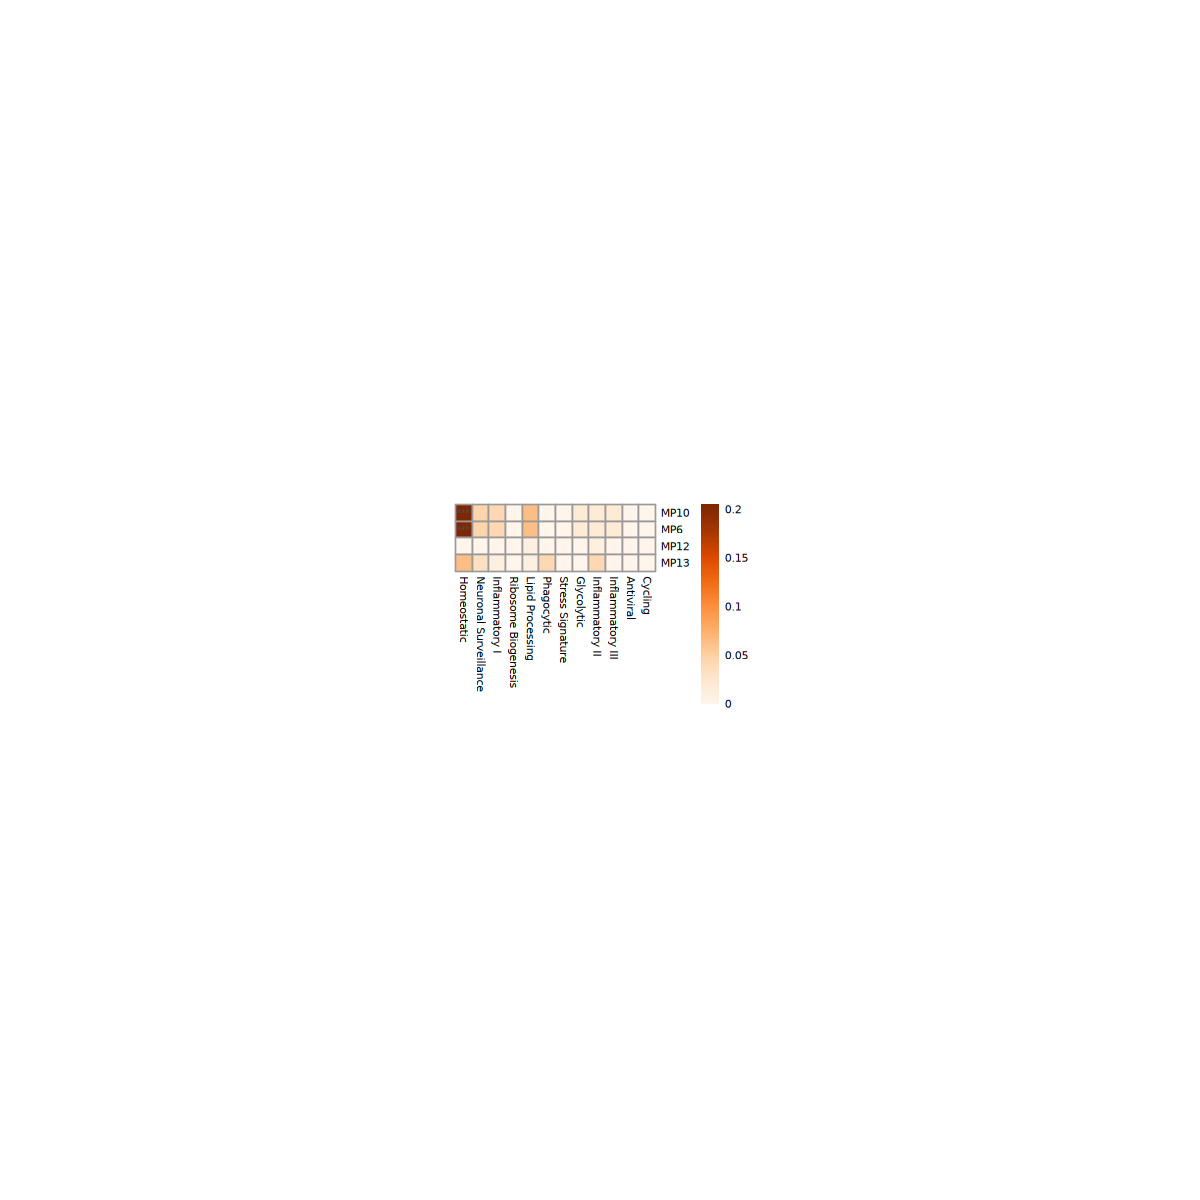

In [30]:
original_oranges <- brewer.pal(9, "Oranges")
colors_oranges <- colorRampPalette(original_oranges)(100)

pheatmap::pheatmap(matrix, cluster_rows = FALSE, cluster_cols = FALSE, 
         number_format = "%.2f", display_numbers = signif_matrix,
         cellwidth = 10, cellheight = 10, fontsize = 6,color = colors_oranges)

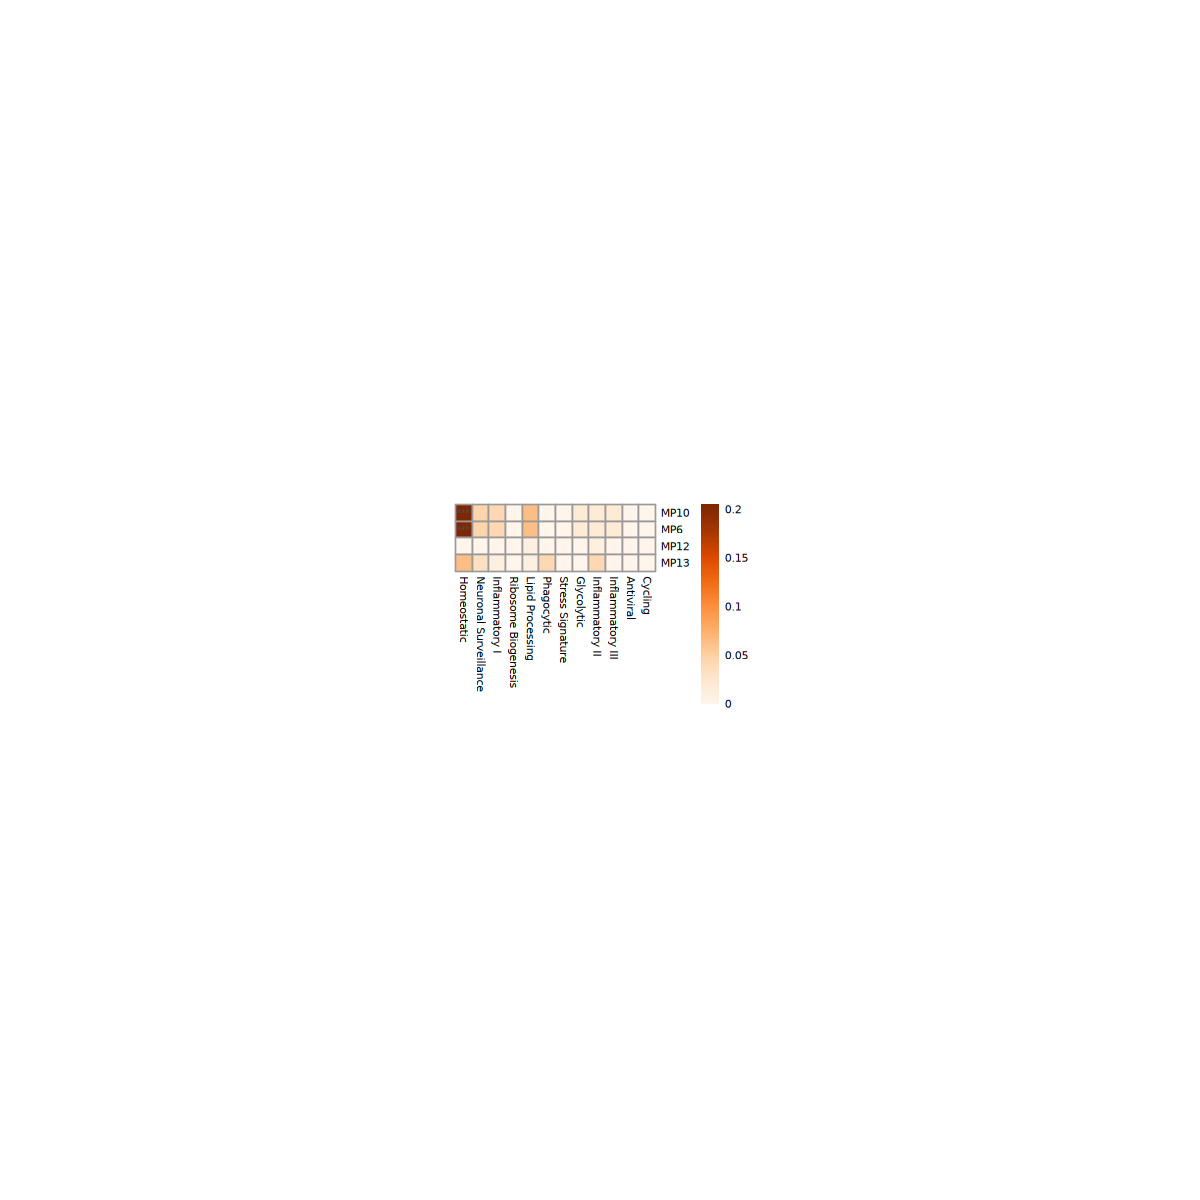

In [31]:
p <- pheatmap::pheatmap(matrix, cluster_rows = FALSE, cluster_cols = FALSE, 
         number_format = "%.2f", display_numbers = signif_matrix,
         cellwidth = 10, cellheight = 10, fontsize = 6,color = colors_oranges)

In [32]:
save_pheatmap_pdf <- function(x, filename, width=7, height=7) {
   stopifnot(!missing(x))
   stopifnot(!missing(filename))
   pdf(filename, width=width, height=height)
   grid::grid.newpage()
   grid::grid.draw(x$gtable)
   dev.off()
}
save_pheatmap_pdf(p, "figures/jaccard_similarity_heatmap_normal_mg_vs_MP.pdf")

png 
  2